# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV,
    GridSearchCV, KFold, cross_val_score
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib
import time
import warnings

sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport.")


Semua library berhasil diimport.


# **Data Loading**

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=1WTPM2ZgdMLCloDVQlcO33s9_wTUQdS5M'
df = pd.read_csv(url)


In [ ]:
df_clean = df.copy()

# **Data Wrangling**

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

Check Duplicates

In [ ]:
print(f"Duplicated: {df_clean.duplicated().sum()}")
#there are no duplicates in the data


Duplicated: 0


Data Type Transformation

In [ ]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors='coerce')
df_clean['Month'] = df_clean['Date'].dt.month_name()
df_clean['MonthNum'] = df_clean['Date'].dt.month

df_clean["ship-postal-code"] = df_clean["ship-postal-code"].astype('object')


Divide Dataset

In [ ]:
#data is divided into 2 data set
#one filled with orders sucessfully shiped or still pending
#and another one with orders failed to be shipped, cancelled or returned
status_cond = df_clean["Status"].isin([
    "Cancelled",
    "Shipped - Lost in Transit",
    "Shipped - Rejected by Buyer",
    "Shipped - Returned to Seller",
    "Shipped - Returning to Seller"
])

courier_cond = (df_clean["Courier Status"] == "Cancelled") | (df_clean["Courier Status"].isna())

unshipped_cond = (df_clean["Status"].isin(["Shipped", "Shipping"])) & (df_clean["Courier Status"] == "Unshipped")

failed_to_ship = status_cond | courier_cond | unshipped_cond

#The data is divided into 2 dataset because most missing value and value 0 in Qty and Amount are from Cancelled or failed orders. which could skewed the real distribution
#Failed order also does not contribute to total amoun but could still be analysed


**Transaction Separation Status**

In [ ]:
df_failed = df_clean[failed_to_ship].copy()
df_shipped = df_clean[~failed_to_ship].copy()

print(f"Number of Failed Orders (df_failed)      : {df_failed.shape[0]} transaction")
print(f"Number of Successful Orders (df_shipped) : {df_shipped.shape[0]} transaction\n")


Number of Failed Orders (df_failed)      : 20672 transaction
Number of Successful Orders (df_shipped) : 108303 transaction



**Data Cleaning on Shipped Orders**

In [ ]:
df_model = df_shipped.copy()

Removing Irrelevant Columns

In [ ]:
drop_cols = ['index', 'Order ID', 'Unnamed: 22', 'ship-postal-code', 'SKU', 'ASIN', 'Style', 'currency']
df_model.drop(columns=drop_cols, inplace=True, errors='ignore')


Missing Values Identification

In [ ]:
missing_df = pd.DataFrame({
    "missing_value": df_model.isnull().sum(),
    # denominator diganti len(df_model) agar persentase dihitung dari shipped orders saja, bukan seluruh dataset asli
    "missing_value_percentage": df_model.isnull().sum() / len(df_model) * 100
})
print(missing_df)


                    missing_value  missing_value_percentage
Date                            0                  0.000000
Status                          0                  0.000000
Fulfilment                      0                  0.000000
Sales Channel                   0                  0.000000
ship-service-level              0                  0.000000
Category                        0                  0.000000
Size                            0                  0.000000
Courier Status                  0                  0.000000
Qty                             0                  0.000000
Amount                          0                  0.000000
ship-city                      23                  0.021237
ship-state                     23                  0.021237
ship-country                   23                  0.021237
promotion-ids               30957                 28.583696
B2B                             0                  0.000000
fulfilled-by                78009       

Missing Values & Handling Inconsistency

In [ ]:
df_model['Discounted'] = np.where(df_model['promotion-ids'].notna() & (df_model['promotion-ids'] != ''), 1, 0)
df_model.drop(columns=['promotion-ids'], inplace=True, errors='ignore')


In [ ]:
if 'fulfilled-by' in df_model.columns:
    df_model['fulfilled-by'].fillna('other', inplace=True)
#set null data in fulfilled-by means the shipment is shipped by other couriers rather than Easy ship

location = ['ship-city', 'ship-state', 'ship-country']
for col in location:
    if col in df_model.columns:
        df_model[col].fillna('unknown', inplace=True)
        df_model[col] = df_model[col].str.upper()
#set null data in city, state and country into unknown because the sale could still be completed even though we don't know where the order was sent


In [ ]:
df_model.dropna(subset=['Amount', 'Courier Status'], inplace=True)

#Make sure the transaction amount is reasonable
df_model = df_model[df_model['Amount'] > 0]


Data Quality Status

In [ ]:
print(f"Remaining Missing Values : {df_model.isnull().sum().max()}")
print(f"Clean Data Dimensions    : {df_model.shape}\n")


Remaining Missing Values : 0
Clean Data Dimensions    : (106015, 18)



In [ ]:
df_model.head(11)

,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,Amount,ship-city,ship-state,ship-country,B2B,fulfilled-by,Month,MonthNum,Discounted
1,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,kurta,3XL,Shipped,1,406.0,BENGALURU,KARNATAKA,IN,False,Easy Ship,April,4,1
2,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,kurta,XL,Shipped,1,329.0,NAVI MUMBAI,MAHARASHTRA,IN,True,other,April,4,1
4,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Top,3XL,Shipped,1,574.0,CHENNAI,TAMIL NADU,IN,False,other,April,4,0
5,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Set,XL,Shipped,1,824.0,GHAZIABAD,UTTAR PRADESH,IN,False,other,April,4,1
6,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Set,L,Shipped,1,653.0,CHANDIGARH,CHANDIGARH,IN,False,other,April,4,1
7,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,kurta,S,Shipped,1,399.0,HYDERABAD,TELANGANA,IN,False,Easy Ship,April,4,1
9,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,kurta,XXL,Shipped,1,363.0,CHENNAI,TAMIL NADU,IN,False,other,April,4,0
10,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,kurta,S,Shipped,1,685.0,CHENNAI,TAMIL NADU,IN,False,other,April,4,0
11,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,kurta,XS,Shipped,1,364.0,NOIDA,UTTAR PRADESH,IN,False,other,April,4,0
12,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,kurta,XS,Shipped,1,399.0,AMRAVATI.,MAHARASHTRA,IN,False,Easy Ship,April,4,1


# **Feature Selection & Engineering**

> **[DIUBAH] Section ini dipindah ke sini** (sebelumnya ada di bawah Hypothesis Testing).  
> Pemindahan ini **wajib** karena `feature_cols` dipakai di section Hypothesis Testing —
> kalau tetap di bawah, notebook akan crash dengan `NameError: name 'feature_cols' is not defined`.


**Feature Selection**

In [ ]:
exclude_cols = [
    'Amount',             # Target variable
    'Date',               # Sudah diekstrak ke Month & MonthNum
    'ship-city',          # Kardinalitas sangat tinggi
    'ship-state',         # Kardinalitas sangat tinggi
    'ship-country',       # Hampir semua IN
    'Status',             # Post-transaction (data leakage)
    'Courier Status',     # Post-transaction (data leakage)
    'Month',              # Akan diganti dengan cyclical encoding
]

feature_cols = [col for col in df_model.columns if col not in exclude_cols]
print("Fitur yang digunakan:", feature_cols)


Fitur yang digunakan: ['Fulfilment', 'Sales Channel ', 'ship-service-level', 'Category', 'Size', 'Qty', 'B2B', 'fulfilled-by', 'MonthNum', 'Discounted']


**Feature Engineering**

In [ ]:
# ─── Feature Engineering ──────────────────────────────────────────────────────
x_raw = df_model[feature_cols].copy()

# 1. Boolean B2B → integer
x_raw['B2B'] = x_raw['B2B'].astype(int)

# 2. Ordinal Encoding: Size (ada urutan alami XS < S < ... < 6XL)
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
size_map = {s: i for i, s in enumerate(size_order)}
x_raw['Size'] = x_raw['Size'].map(size_map).fillna(len(size_order))  # unknown → max+1

# 3. Ordinal Encoding: ship-service-level (Standard < Expedited)
service_map = {'Standard': 0, 'Expedited': 1}
x_raw['ship-service-level'] = x_raw['ship-service-level'].map(service_map).fillna(0)

# 4. Cyclical Encoding: MonthNum → sin/cos (agar Desember & Januari berdekatan)
x_raw['Month_sin'] = np.sin(2 * np.pi * x_raw['MonthNum'] / 12)
x_raw['Month_cos'] = np.cos(2 * np.pi * x_raw['MonthNum'] / 12)
x_raw.drop(columns=['MonthNum'], inplace=True)

# 5. Label Encoding untuk fitur kategorik sisa (Random Forest tidak perlu OHE)
cat_features = ['Category', 'Fulfilment', 'Sales Channel ', 'fulfilled-by']
le_dict = {}
for col in cat_features:
    if col in x_raw.columns:
        le = LabelEncoder()
        x_raw[col] = le.fit_transform(x_raw[col].astype(str))
        le_dict[col] = le

print(f"Jumlah fitur SEBELUM encoding : {len(feature_cols)}")
print(f"Jumlah fitur SETELAH encoding : {x_raw.shape[1]}")
print(f"\nDaftar fitur final:")
for col in x_raw.columns:
    print(f"  - {col} ({x_raw[col].dtype})")


Jumlah fitur SEBELUM encoding : 10
Jumlah fitur SETELAH encoding : 11

Daftar fitur final:
  - Fulfilment (int64)
  - Sales Channel  (int64)
  - ship-service-level (int64)
  - Category (int64)
  - Size (int64)
  - Qty (int64)
  - B2B (int64)
  - fulfilled-by (int64)
  - Discounted (int64)
  - Month_sin (float64)
  - Month_cos (float64)


In [ ]:
# x, y split
x = x_raw.copy()
y = df_model['Amount'].copy()

print(f"Shape x (Fitur)  : {x.shape}")
print(f"Shape y (Target) : {y.shape}")
print(f"\nRange Amount: {y.min():.0f} – {y.max():.0f} INR | Median: {y.median():.0f} INR")


Shape x (Fitur)  : (106015, 11)
Shape y (Target) : (106015,)

Range Amount: 199 – 5584 INR | Median: 625 INR


**Data Splitting 80:20**

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

print(f"x_train : {x_train.shape[0]:>6,} rows × {x_train.shape[1]} fitur")
print(f"x_test  : {x_test.shape[0]:>6,} rows × {x_test.shape[1]} fitur")
print(f"y_train : {y_train.shape[0]:>6,} scores")
print(f"y_test  : {y_test.shape[0]:>6,} scores")
print(f"Proporsi Train : {x_train.shape[0] / x.shape[0]:.1%}")
print(f"Proporsi Test  : {x_test.shape[0]  / x.shape[0]:.1%}")


x_train : 84,812 rows × 11 fitur
x_test  : 21,203 rows × 11 fitur
y_train : 84,812 scores
y_test  : 21,203 scores
Proporsi Train : 80.0%
Proporsi Test  : 20.0%


# **Advanced Pattern, Trend, and Relationship Analysis**

**Distribusi Target: Amount (INR)**

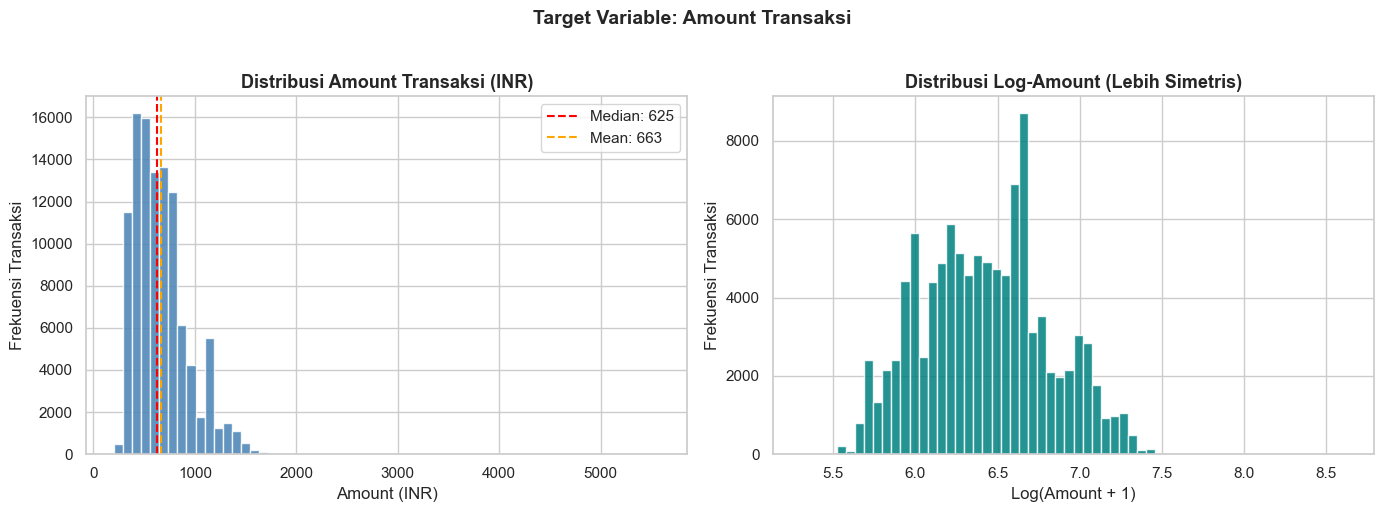

Skewness Amount      : 1.16  (right-skewed, wajar untuk harga)
Skewness Log-Amount  : 0.16


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['Amount'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Amount Transaksi (INR)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount (INR)')
axes[0].set_ylabel('Frekuensi Transaksi')
axes[0].axvline(df_model['Amount'].median(), color='red', linestyle='--', label=f"Median: {df_model['Amount'].median():.0f}")
axes[0].axvline(df_model['Amount'].mean(), color='orange', linestyle='--', label=f"Mean: {df_model['Amount'].mean():.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df_model['Amount']), bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Log-Amount (Lebih Simetris)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Frekuensi Transaksi')

plt.suptitle('Target Variable: Amount Transaksi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness Amount      : {df_model['Amount'].skew():.2f}  (right-skewed, wajar untuk harga)")
print(f"Skewness Log-Amount  : {np.log1p(df_model['Amount']).skew():.2f}")


**Distribusi Kuantitas Pembelian (Qty)**

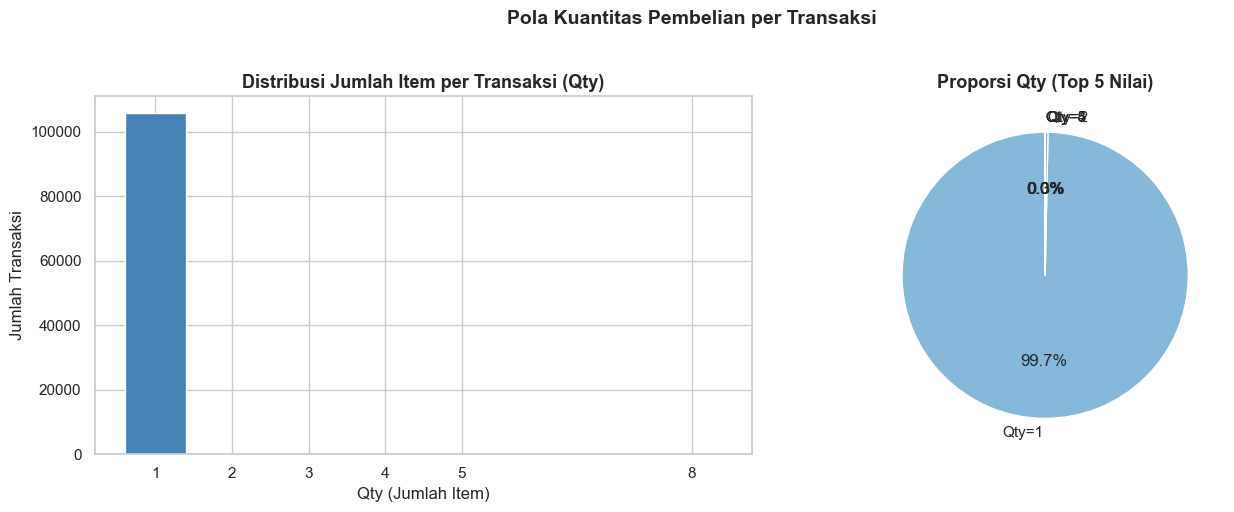

Rata-rata Qty per transaksi : 1.00
Qty terbanyak               : 1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qty_counts = df_model['Qty'].value_counts().sort_index()
axes[0].bar(qty_counts.index, qty_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Item per Transaksi (Qty)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Qty (Jumlah Item)')
axes[0].set_ylabel('Jumlah Transaksi')
axes[0].set_xticks(qty_counts.index)

axes[1].pie(
    qty_counts.values[:5],
    labels=[f"Qty={i}" for i in qty_counts.index[:5]],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Blues_d", 5)
)
axes[1].set_title('Proporsi Qty (Top 5 Nilai)', fontsize=13, fontweight='bold')

plt.suptitle('Pola Kuantitas Pembelian per Transaksi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Rata-rata Qty per transaksi : {df_model['Qty'].mean():.2f}")
print(f"Qty terbanyak               : {df_model['Qty'].mode()[0]}")


**Volume Penjualan per Kategori Produk (Berbasis Qty)**

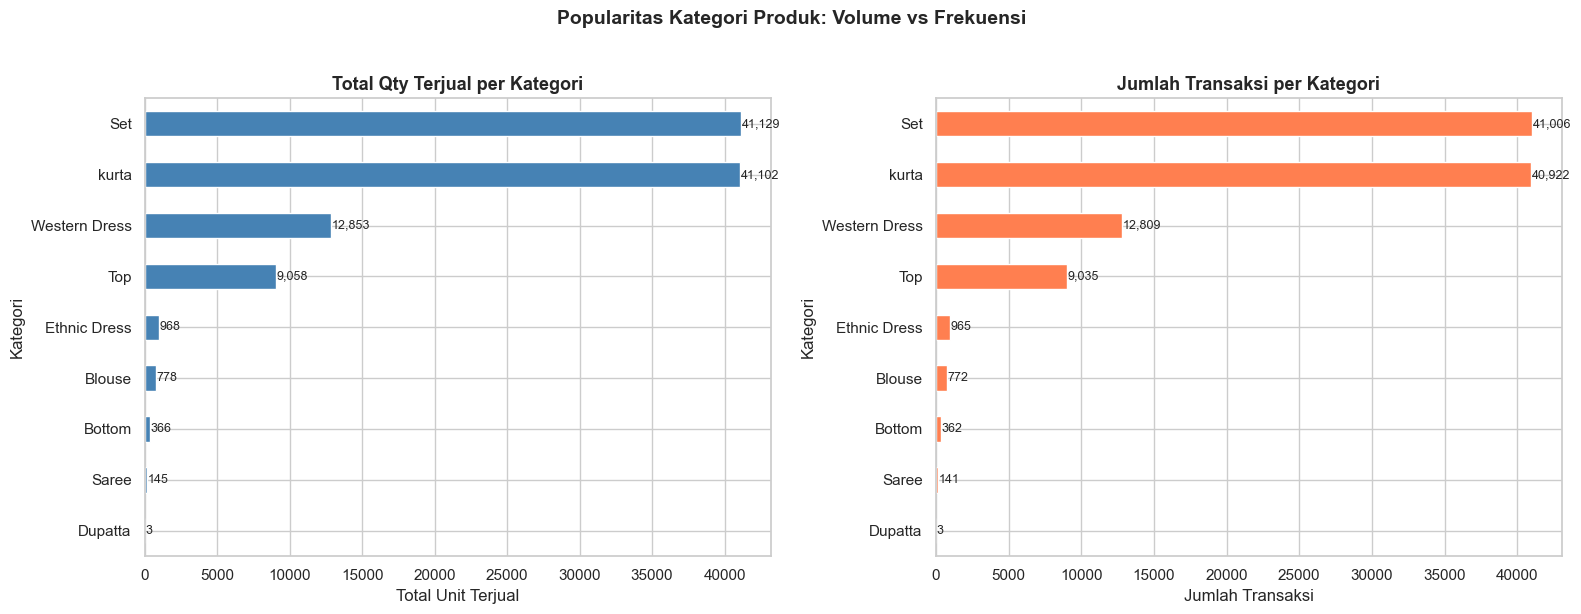


Top 3 Kategori (Qty): {'Set': 41129, 'kurta': 41102, 'Western Dress': 12853}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_qty = df_model.groupby('Category')['Qty'].sum().sort_values(ascending=False)
cat_txn = df_model.groupby('Category')['Amount'].count().sort_values(ascending=False)

cat_qty.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Total Qty Terjual per Kategori', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Unit Terjual')
axes[0].set_ylabel('Kategori')
for i, v in enumerate(cat_qty):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

cat_txn.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Jumlah Transaksi per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi')
axes[1].set_ylabel('Kategori')
for i, v in enumerate(cat_txn):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Popularitas Kategori Produk: Volume vs Frekuensi', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nTop 3 Kategori (Qty):", cat_qty.head(3).to_dict())


**Harga Median per Kategori & Size**

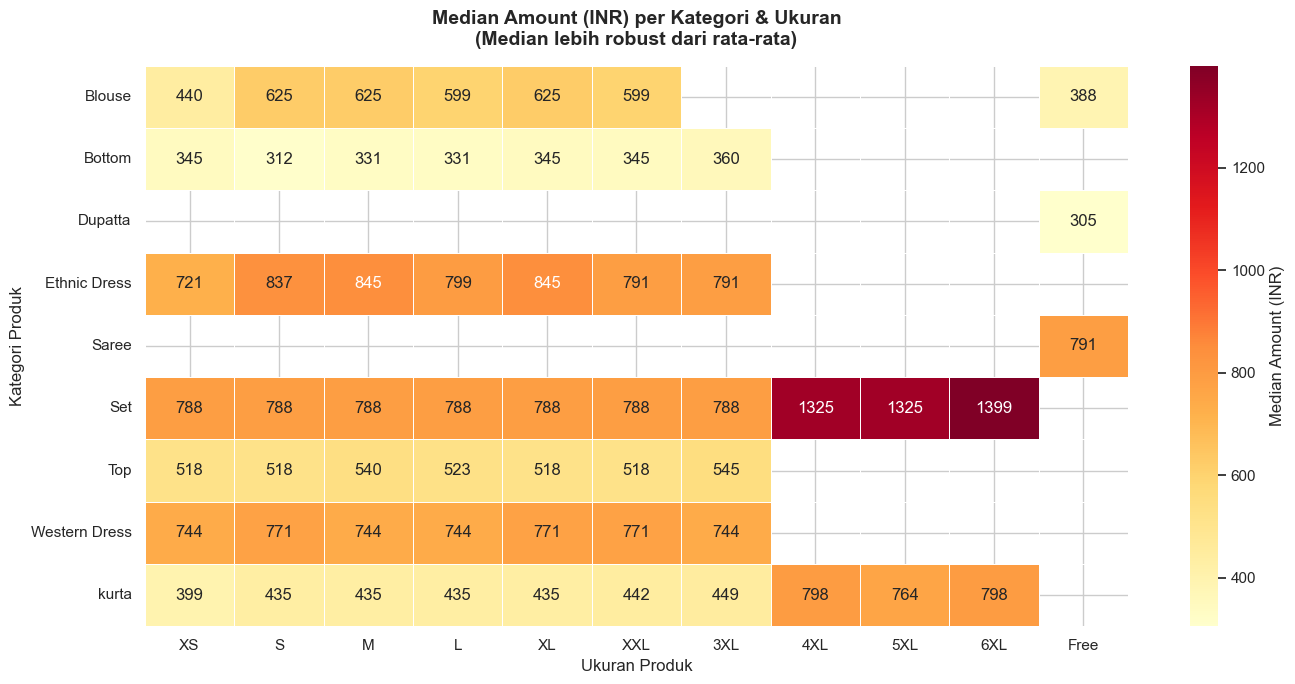

In [ ]:
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']

pivot_median = df_model.pivot_table(
    index='Category', columns='Size', values='Amount',
    aggfunc='median'
)
pivot_median = pivot_median.reindex(columns=[s for s in size_order if s in pivot_median.columns])

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_median,
    cmap='YlOrRd', annot=True, fmt=".0f", linewidths=.5,
    cbar_kws={'label': 'Median Amount (INR)'}
)
plt.title('Median Amount (INR) per Kategori & Ukuran\n(Median lebih robust dari rata-rata)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ukuran Produk')
plt.ylabel('Kategori Produk')
plt.tight_layout()
plt.show()


**Tren Bulanan: Volume Penjualan (Qty) — Top 3 Kategori**

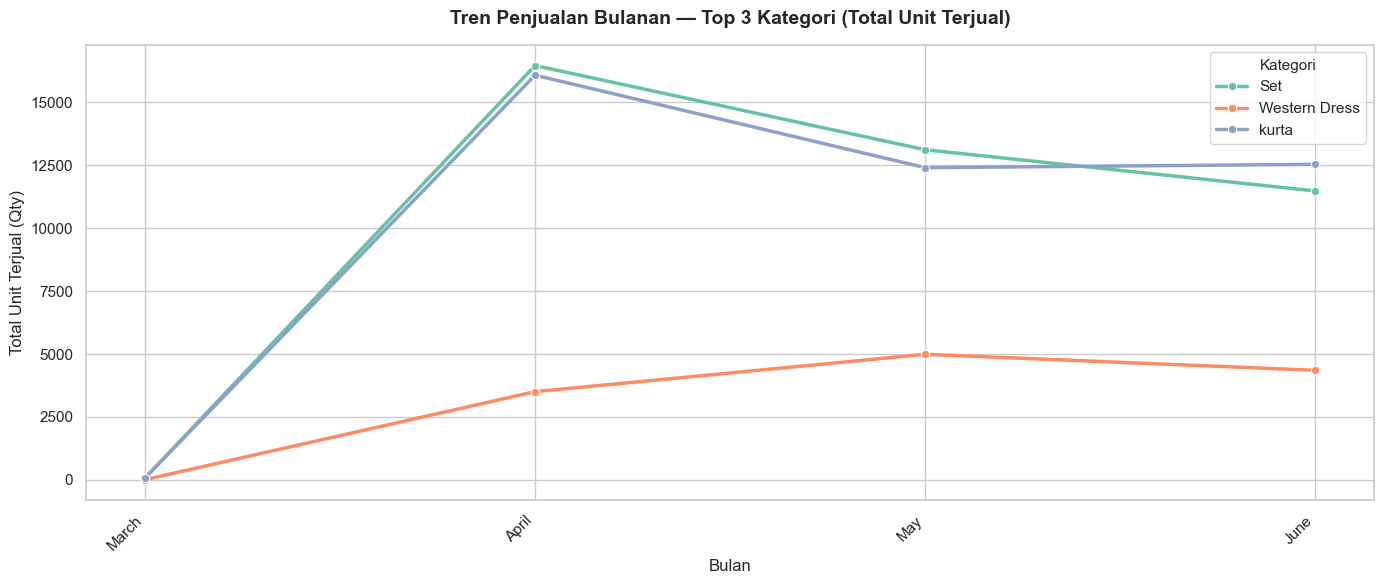

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

top_3_cat = df_model['Category'].value_counts().nlargest(3).index
df_trend = df_model[df_model['Category'].isin(top_3_cat)].copy()

monthly_qty = df_trend.groupby(['Month', 'Category'])['Qty'].sum().reset_index()
monthly_qty['Month'] = pd.Categorical(monthly_qty['Month'], categories=month_order, ordered=True)
monthly_qty = monthly_qty.sort_values('Month')

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_qty, x='Month', y='Qty', hue='Category',
             linewidth=2.5, marker='o', palette='Set2')
plt.title('Tren Penjualan Bulanan — Top 3 Kategori (Total Unit Terjual)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Bulan')
plt.ylabel('Total Unit Terjual (Qty)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Kategori', title_fontsize=11)
plt.tight_layout()
plt.show()


**Distribusi Pembelian per Ukuran (Size)**

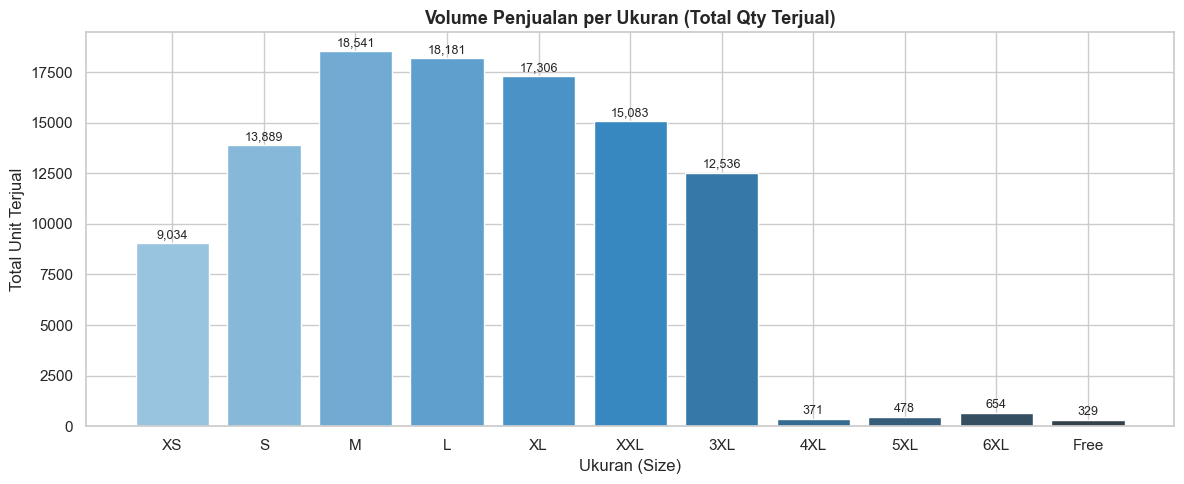

In [ ]:
size_order = ['XS', 'S', 'M', 'L', 'XL', 'XXL', '3XL', '4XL', '5XL', '6XL', 'Free']
size_qty = df_model.groupby('Size')['Qty'].sum().reindex(
    [s for s in size_order if s in df_model['Size'].unique()]
)

plt.figure(figsize=(12, 5))
bars = plt.bar(size_qty.index, size_qty.values, color=sns.color_palette("Blues_d", len(size_qty)), edgecolor='white')
plt.title('Volume Penjualan per Ukuran (Total Qty Terjual)', fontsize=13, fontweight='bold')
plt.xlabel('Ukuran (Size)')
plt.ylabel('Total Unit Terjual')
for bar, val in zip(bars, size_qty.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


**B2B vs B2C: Perbandingan Pola Transaksi**

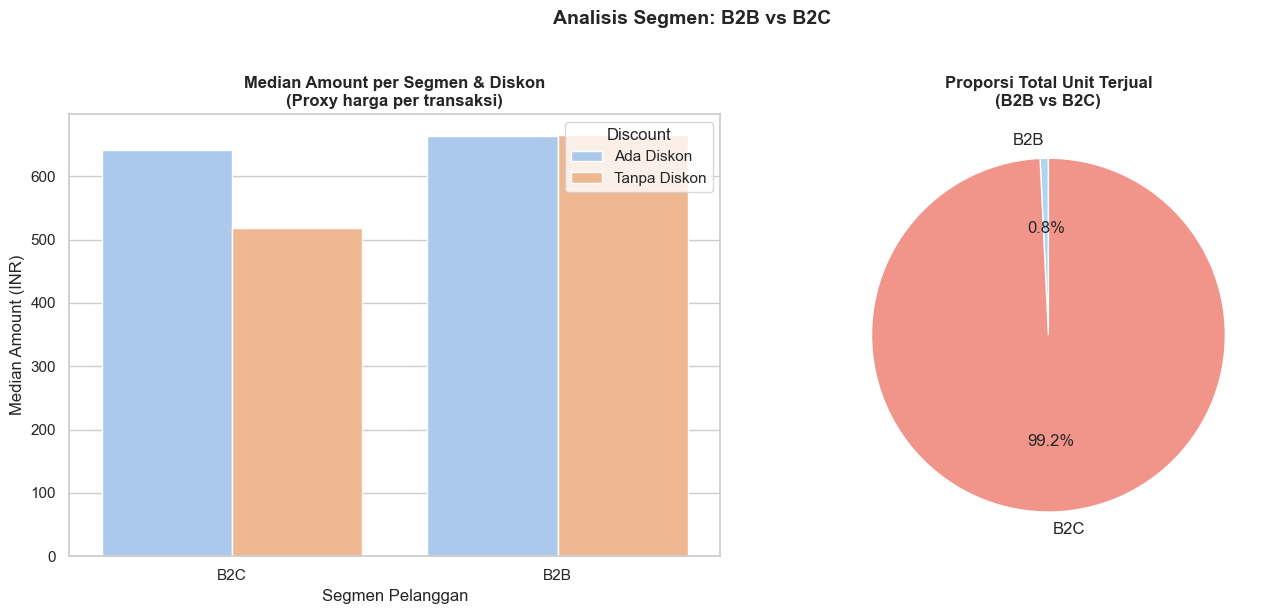

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_b2b = df_model.copy()
df_b2b['Segment'] = df_b2b['B2B'].map({True: 'B2B', False: 'B2C'})
df_b2b['Discount'] = df_b2b['Discounted'].map({1: 'Ada Diskon', 0: 'Tanpa Diskon'})

sns.barplot(data=df_b2b, x='Segment', y='Amount', hue='Discount',
            estimator=np.median, errorbar=None, palette='pastel', ax=axes[0])
axes[0].set_title('Median Amount per Segmen & Diskon\n(Proxy harga per transaksi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Segmen Pelanggan')
axes[0].set_ylabel('Median Amount (INR)')

seg_qty = df_b2b.groupby('Segment')['Qty'].sum()
axes[1].pie(seg_qty.values, labels=seg_qty.index, autopct='%1.1f%%',
            colors=['#AED6F1', '#F1948A'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proporsi Total Unit Terjual\n(B2B vs B2C)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Segmen: B2B vs B2C', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# **Hypothesis Testing**

> - Normality check (Shapiro-Wilk + Q-Q Plot) sebelum memilih jenis uji.
> - ANOVA test + Tukey HSD post-hoc untuk perbandingan Amount antar kategori.
> - Chi-Square test untuk asosiasi B2B vs Diskon.
> - Visualisasi koefisien OLS (signifikan vs tidak signifikan).


## 1. Normality Check

Sebelum memilih jenis uji statistik, kita periksa terlebih dahulu apakah distribusi `Amount`
mendekati normal, karena pemilihan t-test vs Mann-Whitney bergantung pada asumsi ini.

- **Shapiro-Wilk test**: uji formal normalitas (subsample ≤ 5000, karena Shapiro tidak efisien untuk n besar)
- **Q-Q Plot**: visualisasi untuk melihat seberapa jauh distribusi menyimpang dari normal

In [ ]:
# Normality check menggunakan Shapiro-Wilk dan Q-Q Plot
testing_df = df_model.dropna(subset=['Discounted', 'Amount', 'Qty']).copy()

group_A = testing_df[testing_df['Discounted'] == 0]  # Control: tanpa diskon
group_B = testing_df[testing_df['Discounted'] == 1]  # Treatment: ada diskon

# Subsample max 5000 untuk Shapiro-Wilk
rng      = np.random.default_rng(42)
n_sample = min(5000, len(group_A), len(group_B))
s_A = rng.choice(group_A['Amount'].values, size=n_sample, replace=False)
s_B = rng.choice(group_B['Amount'].values, size=n_sample, replace=False)

stat_A, p_norm_A = stats.shapiro(s_A)
stat_B, p_norm_B = stats.shapiro(s_B)

print("=" * 60)
print("       SHAPIRO-WILK NORMALITY TEST")
print("=" * 60)
print(f"  Group A (No Discount)   W={stat_A:.4f}, p={p_norm_A:.6f}  → {'NORMAL ✓' if p_norm_A > 0.05 else 'TIDAK NORMAL ✗'}")
print(f"  Group B (With Discount) W={stat_B:.4f}, p={p_norm_B:.6f}  → {'NORMAL ✓' if p_norm_B > 0.05 else 'TIDAK NORMAL ✗'}")
print()
print("Interpretasi:")
print("  p < 0.05  → distribusi TIDAK normal → gunakan Mann-Whitney U (non-parametrik)")
print("  p ≥ 0.05  → distribusi normal → t-test valid")


       SHAPIRO-WILK NORMALITY TEST
  Group A (No Discount)   W=0.8785, p=0.000000  → TIDAK NORMAL ✗
  Group B (With Discount) W=0.9342, p=0.000000  → TIDAK NORMAL ✗

Interpretasi:
  p < 0.05  → distribusi TIDAK normal → gunakan Mann-Whitney U (non-parametrik)
  p ≥ 0.05  → distribusi normal → t-test valid


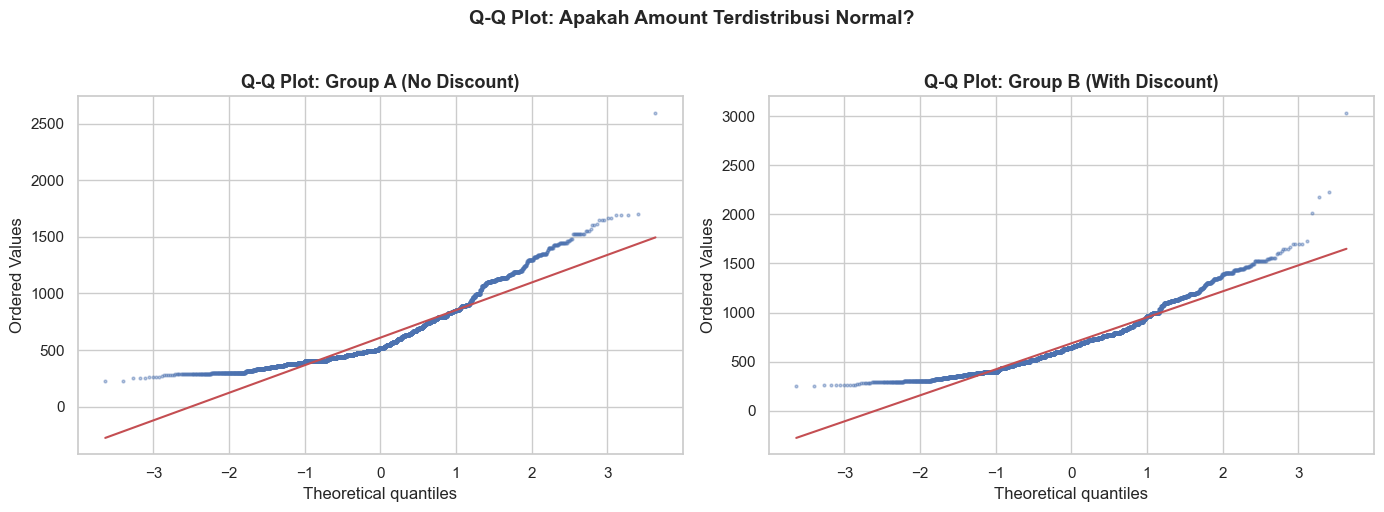

Titik yang menyimpang jauh dari garis merah = distribusi tidak normal.


In [ ]:
# Q-Q Plot untuk visualisasi normalitas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stats.probplot(s_A, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot: Group A (No Discount)', fontsize=13, fontweight='bold')
axes[0].get_lines()[0].set(markersize=2, alpha=0.4)

stats.probplot(s_B, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Group B (With Discount)', fontsize=13, fontweight='bold')
axes[1].get_lines()[0].set(markersize=2, alpha=0.4)

plt.suptitle('Q-Q Plot: Apakah Amount Terdistribusi Normal?', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Titik yang menyimpang jauh dari garis merah = distribusi tidak normal.")


## 2. OLS Regression-Based Hypothesis Testing

Uji apakah setiap fitur secara statistik berpengaruh signifikan terhadap `Amount`
menggunakan **Ordinary Least Squares (OLS)**. P-value tiap koefisien menunjukkan
signifikansinya (H₀: koefisien = 0).

In [ ]:
# Ganti MonthNum dengan Month untuk OLS (Month lebih interpretatif)
tested_cols = [c for c in feature_cols if c != 'MonthNum'] + ['Month']
target_col  = 'Amount'

df_testing = df_model.dropna(subset=tested_cols + [target_col]).copy()

test_cat_cols = ['Fulfilment', 'Sales Channel ', 'ship-service-level', 'Category', 'Size', 'fulfilled-by', 'Month']
test_num_cols = ['Qty', 'B2B', 'Discounted']

df_testing['B2B'] = df_testing['B2B'].astype(int)

# Print baseline (kategori referensi) untuk setiap kolom kategorikal
print("Baseline (kategori referensi) untuk OLS:")
for col in test_cat_cols:
    baseline_value = sorted(df_testing[col].unique())[0]
    print(f"  {col:<25}: {baseline_value}")
print()

# OneHot Encoding untuk OLS (drop_first=True agar tidak multicollinear)
x_cat = pd.get_dummies(df_testing[test_cat_cols], drop_first=True)
x_num = df_testing[test_num_cols]

X_ols = pd.concat([x_cat, x_num], axis=1).astype(float)
X_ols = sm.add_constant(X_ols)
y_ols = df_testing[target_col]

ols_model = sm.OLS(y_ols, X_ols).fit()
print(ols_model.summary())


Baseline (kategori referensi) untuk OLS:
  Fulfilment               : Amazon
  Sales Channel            : Amazon.in
  ship-service-level       : Expedited
  Category                 : Blouse
  Size                     : 3XL
  fulfilled-by             : Easy Ship
  Month                    : April

                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     4046.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:10:02   Log-Likelihood:            -7.0712e+05
No. Observations:              106015   AIC:                         1.414e+06
Df Residuals:                  105988   BIC:                         1.415e+06
Df Model:                          26                                

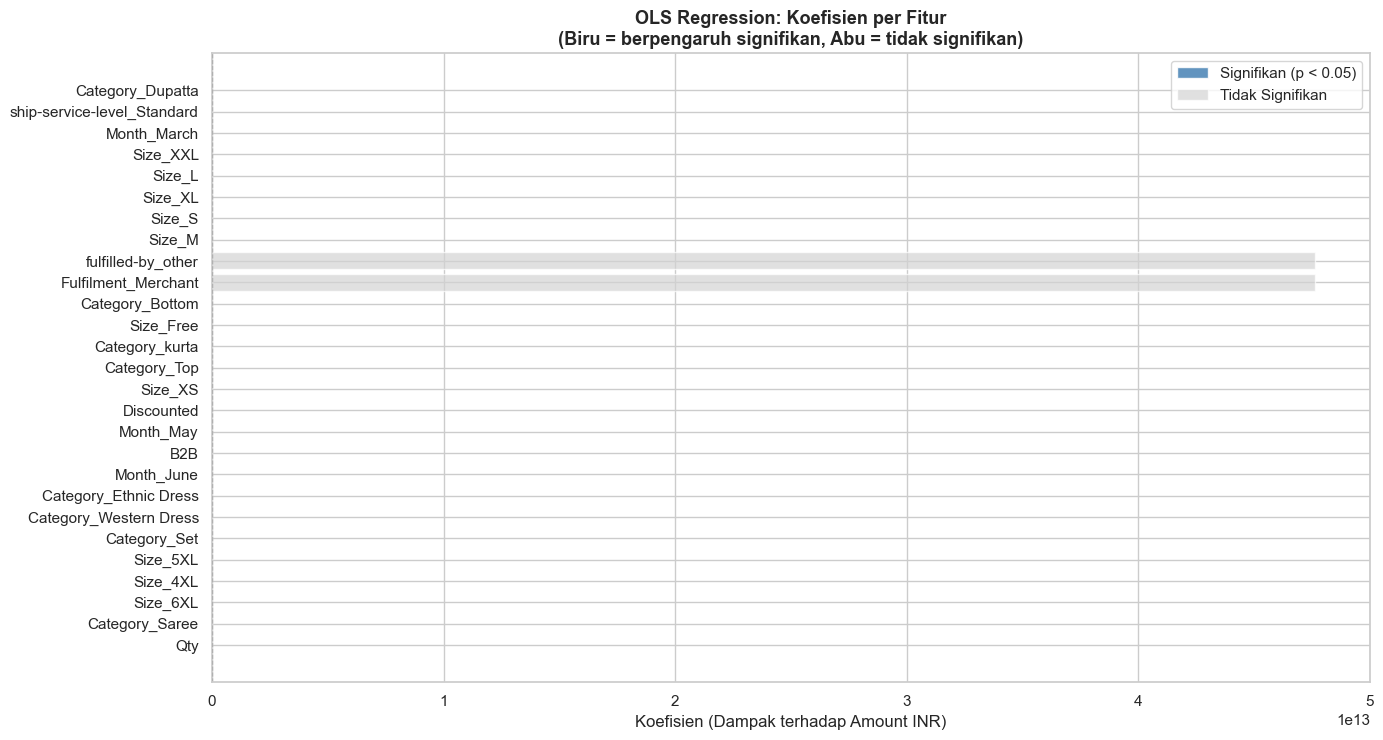

In [ ]:
# Visualisasi koefisien: signifikan vs tidak signifikan
coef_df = pd.DataFrame({
    'Feature' : ols_model.params.index,
    'Coef'    : ols_model.params.values,
    'P-Value' : ols_model.pvalues.values
}).iloc[1:]  # drop const

coef_df['Significant'] = coef_df['P-Value'] < 0.05
coef_df = coef_df.sort_values('Coef', ascending=False)

sig   = coef_df[coef_df['Significant']]
insig = coef_df[~coef_df['Significant']]

plt.figure(figsize=(14, max(6, len(coef_df) * 0.28)))
plt.barh(sig['Feature'],   sig['Coef'],   color='steelblue', label='Signifikan (p < 0.05)', alpha=0.85)
plt.barh(insig['Feature'], insig['Coef'], color='lightgrey',  label='Tidak Signifikan',     alpha=0.7)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('OLS Regression: Koefisien per Fitur\n(Biru = berpengaruh signifikan, Abu = tidak signifikan)',
          fontsize=13, fontweight='bold')
plt.xlabel('Koefisien (Dampak terhadap Amount INR)')
plt.legend()
plt.tight_layout()
plt.show()


## 3. ANOVA Test: Perbedaan Amount antar Kategori Produk

**Hipotesis:**
- H₀: Rata-rata Amount sama di semua kategori produk
- H₁: Minimal satu kategori memiliki rata-rata Amount yang berbeda secara signifikan

Diikuti **Tukey HSD post-hoc test** untuk mengidentifikasi pasangan kategori mana yang berbeda.


In [ ]:
# One-Way ANOVA: apakah Amount berbeda signifikan antar kategori?
categories   = df_model['Category'].dropna().unique()
groups_by_cat = [df_model[df_model['Category'] == cat]['Amount'].dropna().values
                 for cat in categories]

f_stat, p_anova = stats.f_oneway(*groups_by_cat)

print("=" * 55)
print("  ONE-WAY ANOVA: Amount per Kategori Produk")
print("=" * 55)
print(f"  F-Statistic : {f_stat:.4f}")
print(f"  P-Value     : {p_anova:.6f}")
print(f"  Hasil       : {'Signifikan ✓ (H₀ ditolak)' if p_anova < 0.05 else 'Tidak Signifikan ✗'}")
print()
if p_anova < 0.05:
    print("  Interpretasi: minimal ada SATU kategori dengan rata-rata Amount")
    print("  yang berbeda signifikan → lanjut ke Tukey HSD.")
else:
    print("  Interpretasi: tidak ada bukti perbedaan Amount antar kategori.")
print("=" * 55)


  ONE-WAY ANOVA: Amount per Kategori Produk
  F-Statistic : 10812.6091
  P-Value     : 0.000000
  Hasil       : Signifikan ✓ (H₀ ditolak)

  Interpretasi: minimal ada SATU kategori dengan rata-rata Amount
  yang berbeda signifikan → lanjut ke Tukey HSD.


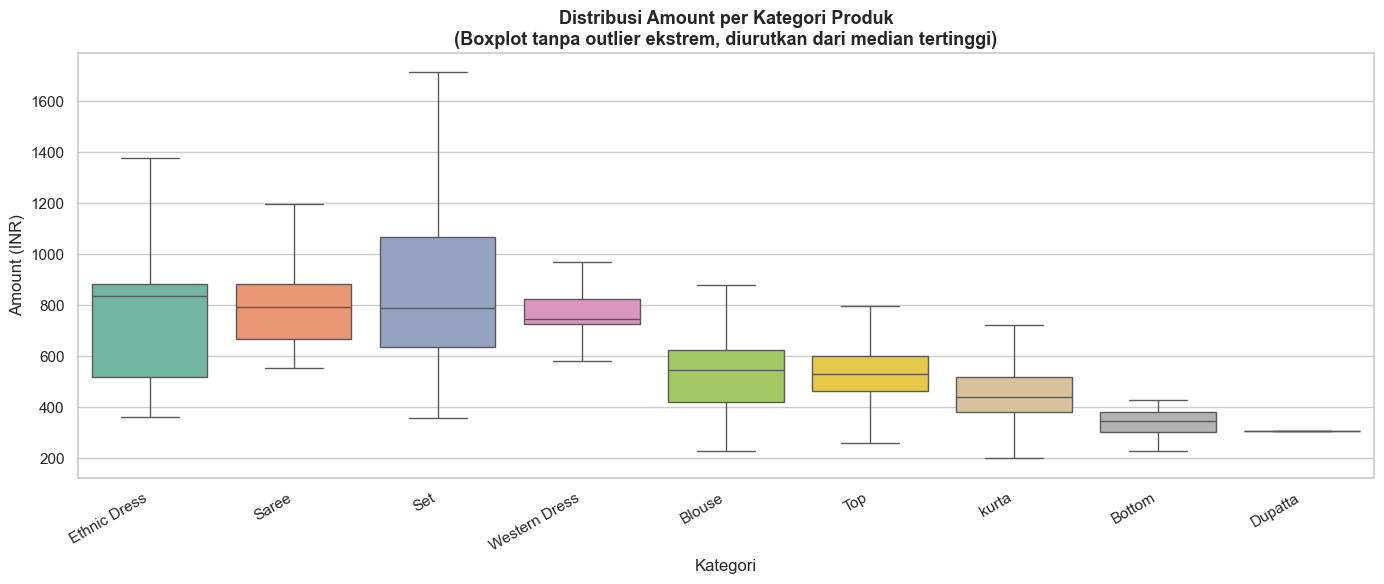

In [ ]:
# Boxplot Amount per kategori (pendukung visual ANOVA)
category_order = df_model.groupby('Category')['Amount'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_model, x='Category', y='Amount',
            order=category_order, palette='Set2', showfliers=False)
plt.title('Distribusi Amount per Kategori Produk\n(Boxplot tanpa outlier ekstrem, diurutkan dari median tertinggi)',
          fontsize=13, fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Tukey HSD Post-Hoc Test (hanya jika ANOVA signifikan)
if p_anova < 0.05:
    df_anova_input = df_model[['Category', 'Amount']].dropna()
    tukey = pairwise_tukeyhsd(
        endog=df_anova_input['Amount'],
        groups=df_anova_input['Category'],
        alpha=0.05
    )
    print("=== Tukey HSD Post-Hoc Test ===")
    print(tukey.summary())
    print()
    print("Interpretasi:")
    print("  reject=True  → pasangan kategori tsb berbeda signifikan dalam Amount (INR).")
    print("  meandiff     → selisih rata-rata Amount antara dua kategori.")
else:
    print("ANOVA tidak signifikan — post-hoc test tidak diperlukan.")


=== Tukey HSD Post-Hoc Test ===
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
    group1        group2     meandiff p-adj    lower     upper   reject
-----------------------------------------------------------------------
       Blouse        Bottom -164.5269    0.0 -204.0115 -125.0423   True
       Blouse       Dupatta -228.2396 0.5614  -586.803  130.3237  False
       Blouse  Ethnic Dress  213.9676    0.0  184.0373   243.898   True
       Blouse         Saree   273.115    0.0  216.3472  329.8827   True
       Blouse           Set  321.0627    0.0  298.5449  343.5805   True
       Blouse           Top    1.9785    1.0  -21.2638   25.2208  False
       Blouse Western Dress  244.2254    0.0  221.2542  267.1966   True
       Blouse         kurta  -66.9802    0.0  -89.4984   -44.462   True
       Bottom       Dupatta  -63.7127 0.9998 -423.0612  295.6358  False
       Bottom  Ethnic Dress  378.4945    0.0  340.2912  416.6979   True
       Bottom         Saree  437

## 4. Chi-Square Test: Hubungan B2B dan Pemberian Diskon

**Hipotesis:**
- H₀: Tidak ada hubungan antara status B2B/B2C dan pemberian diskon
- H₁: Ada hubungan signifikan antara status B2B/B2C dan pemberian diskon

Chi-Square digunakan untuk menguji asosiasi antara dua variabel kategorikal.
Cramer's V digunakan untuk mengukur kekuatan asosiasi (effect size).


In [ ]:
# Chi-Square Test: B2B vs Discounted
df_chi = df_model[['B2B', 'Discounted']].dropna().copy()
df_chi['Segment']  = df_chi['B2B'].map({True: 'B2B', False: 'B2C'})
df_chi['Discount'] = df_chi['Discounted'].map({1: 'Ada Diskon', 0: 'Tanpa Diskon'})

contingency = pd.crosstab(df_chi['Segment'], df_chi['Discount'])
print("Contingency Table (Observed Frequencies):")
print(contingency)
print()

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

# Cramer's V — effect size untuk Chi-Square
n         = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
magnitude = "Lemah" if cramers_v < 0.1 else ("Sedang" if cramers_v < 0.3 else "Kuat")

print("=" * 50)
print("     CHI-SQUARE TEST: B2B vs Discounted")
print("=" * 50)
print(f"  Chi² Statistic           : {chi2:.4f}")
print(f"  Degrees of Freedom       : {dof}")
print(f"  P-Value                  : {p_chi2:.6f}")
print(f"  Hasil                    : {'Signifikan ✓ (H₀ ditolak)' if p_chi2 < 0.05 else 'Tidak Signifikan ✗'}")
print(f"  Cramer's V (Effect Size) : {cramers_v:.4f}  ({magnitude})")
print("=" * 50)
if p_chi2 < 0.05:
    print("\nInterpretasi: ada asosiasi signifikan antara status B2B/B2C dan pemberian diskon.")


Contingency Table (Observed Frequencies):
Discount  Ada Diskon  Tanpa Diskon
Segment                           
B2B              538           250
B2C            76081         29146

     CHI-SQUARE TEST: B2B vs Discounted
  Chi² Statistic           : 6.1321
  Degrees of Freedom       : 1
  P-Value                  : 0.013275
  Hasil                    : Signifikan ✓ (H₀ ditolak)
  Cramer's V (Effect Size) : 0.0076  (Lemah)

Interpretasi: ada asosiasi signifikan antara status B2B/B2C dan pemberian diskon.


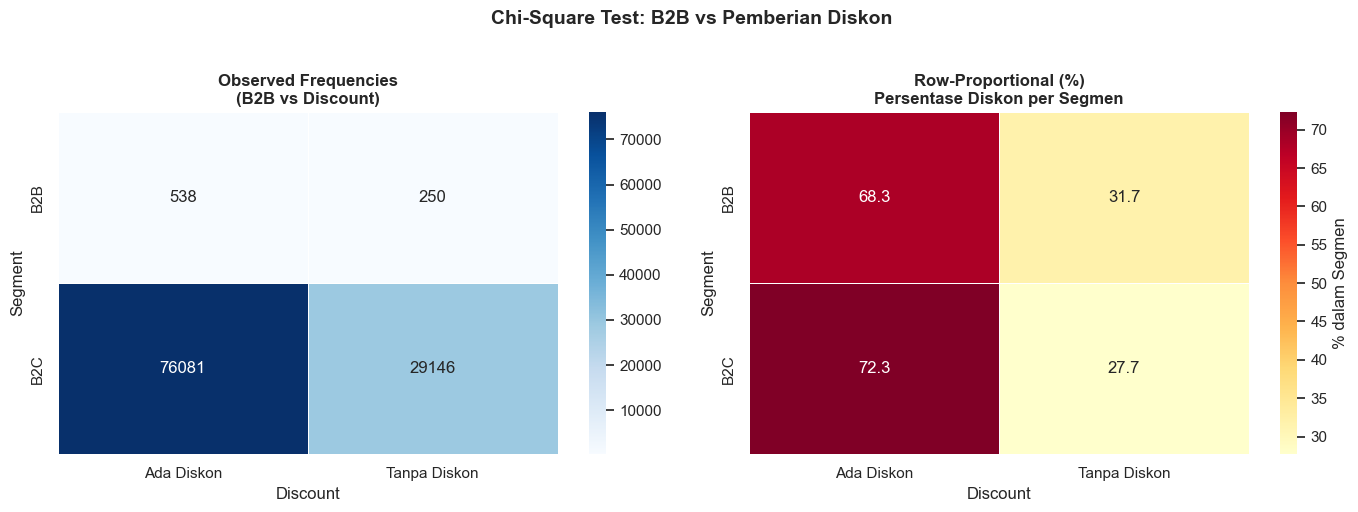

In [ ]:
# Heatmap contingency table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=axes[0], linewidths=0.5)
axes[0].set_title('Observed Frequencies\n(B2B vs Discount)', fontsize=12, fontweight='bold')

contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], linewidths=0.5,
            cbar_kws={'label': '% dalam Segmen'})
axes[1].set_title('Row-Proportional (%)\nPersentase Diskon per Segmen', fontsize=12, fontweight='bold')

plt.suptitle('Chi-Square Test: B2B vs Pemberian Diskon', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# **Experiment (A/B) Testing**

In [ ]:
# Helper: Cohen's d untuk effect size
def cohen_d(x, y):
    """Standardized mean difference antara dua grup."""
    nx, ny     = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1) * x.std(ddof=1)**2 + (ny - 1) * y.std(ddof=1)**2) / (nx + ny - 2)
    )
    return (x.mean() - y.mean()) / pooled_std

# Group A = Control (tanpa diskon), Group B = Treatment (ada diskon)
group_A = testing_df[testing_df['Discounted'] == 0]
group_B = testing_df[testing_df['Discounted'] == 1]

print("=" * 65)
print("             A/B TESTING — KPI SUMMARY")
print("=" * 65)
print(f"  {'Metric':<30} {'Group A (No Disc)':>16} {'Group B (Disc)':>14}")
print("-" * 65)
for label, col in [("Avg Amount (INR)", "Amount"), ("Avg Qty", "Qty")]:
    vA = group_A[col].mean()
    vB = group_B[col].mean()
    print(f"  {label:<30} {vA:>16.2f} {vB:>14.2f}")
print(f"  {'Sample Size':<30} {len(group_A):>16,} {len(group_B):>14,}")
print("=" * 65)


             A/B TESTING — KPI SUMMARY
  Metric                         Group A (No Disc) Group B (Disc)
-----------------------------------------------------------------
  Avg Amount (INR)                         615.83         681.08
  Avg Qty                                    1.00           1.00
  Sample Size                              29,396         76,619


In [ ]:
# Statistical tests + effect size untuk Amount dan Qty
results_ab = []
for col, label in [("Amount", "Transaction Amount (INR)"), ("Qty", "Quantity Ordered")]:
    a_vals = group_A[col].dropna()
    b_vals = group_B[col].dropna()

    # Welch's t-test (tetap dijalankan sebagai pembanding)
    t_stat, p_ttest = stats.ttest_ind(a_vals, b_vals, equal_var=False)
    # [DITAMBAH] Mann-Whitney U — lebih robust untuk data tidak normal
    u_stat, p_mwu   = stats.mannwhitneyu(a_vals, b_vals, alternative='two-sided')
    # [DITAMBAH] Cohen's d — effect size
    d         = cohen_d(a_vals, b_vals)
    magnitude = "Kecil" if abs(d) < 0.2 else ("Sedang" if abs(d) < 0.5 else "Besar")

    results_ab.append({
        "Metric": label, "Mean A": a_vals.mean(), "Mean B": b_vals.mean(),
        "t-stat": t_stat, "p (t-test)": p_ttest,
        "p (Mann-Whitney)": p_mwu, "Cohen's d": d, "Effect Size": magnitude
    })

alpha = 0.05
print("\n=== STATISTICAL TEST RESULTS ===")
for r in results_ab:
    sig_ttest = r['p (t-test)'] < alpha
    sig_mwu   = r['p (Mann-Whitney)'] < alpha
    print(f"\n  Metric          : {r['Metric']}")
    print(f"  Mean A          : {r['Mean A']:.4f}")
    print(f"  Mean B          : {r['Mean B']:.4f}")
    print(f"  Δ Mean (B − A)  : {r['Mean B'] - r['Mean A']:+.4f}")
    print(f"  Welch t-test    : t={r['t-stat']:.4f}, p={r['p (t-test)']:.6f}  → {'Signifikan ✓' if sig_ttest else 'Tidak Signifikan ✗'}")
    print(f"  Mann-Whitney U  : p={r['p (Mann-Whitney)']:.6f}  → {'Signifikan ✓' if sig_mwu else 'Tidak Signifikan ✗'}")
    print(f"  Cohen's d       : {r["Cohen's d"]:.4f}  ({r['Effect Size']})")



=== STATISTICAL TEST RESULTS ===

  Metric          : Transaction Amount (INR)
  Mean A          : 615.8333
  Mean B          : 681.0817
  Δ Mean (B − A)  : +65.2484
  Welch t-test    : t=-35.5410, p=0.000000  → Signifikan ✓
  Mann-Whitney U  : p=0.000000  → Signifikan ✓
  Cohen's d       : -0.2437  (Sedang)

  Metric          : Quantity Ordered
  Mean A          : 1.0015
  Mean B          : 1.0045
  Δ Mean (B − A)  : +0.0030
  Welch t-test    : t=-7.0511, p=0.000000  → Signifikan ✓
  Mann-Whitney U  : p=0.000000  → Signifikan ✓
  Cohen's d       : -0.0423  (Kecil)


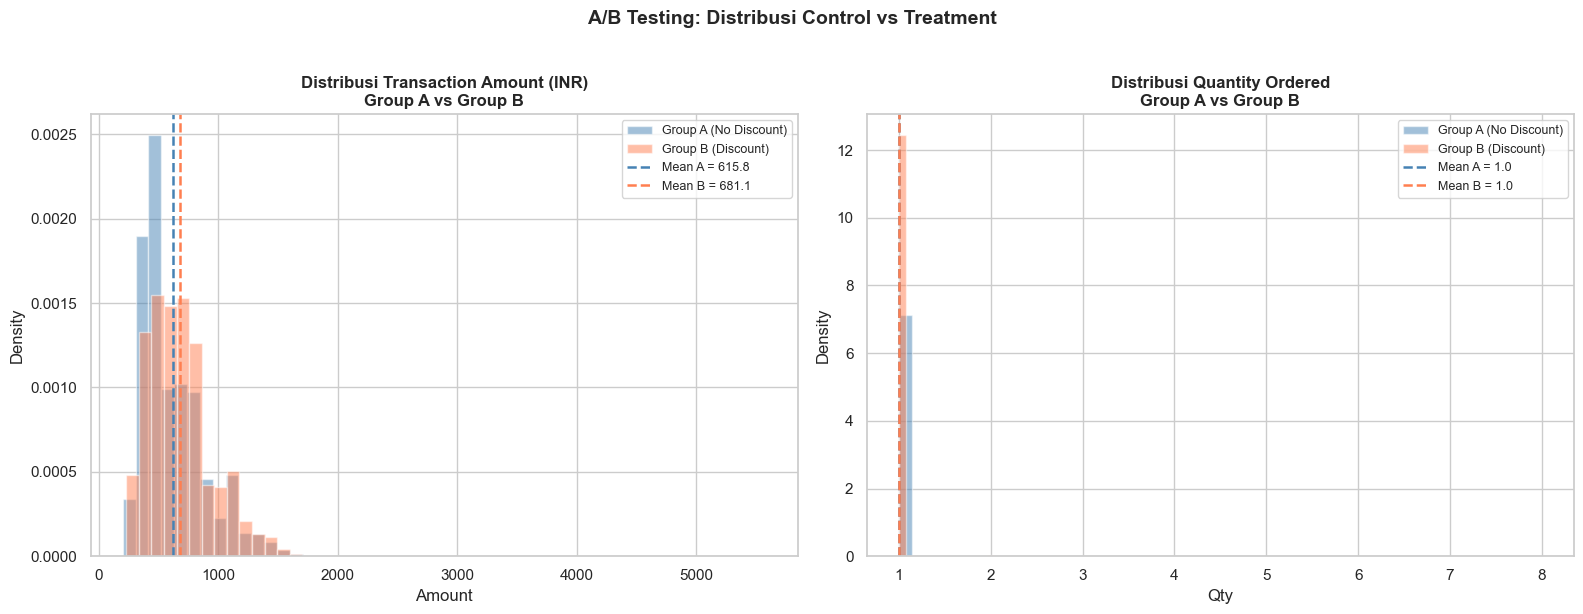

In [ ]:
# Visualisasi distribusi Group A vs Group B
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, title in zip(
    axes,
    ["Amount", "Qty"],
    ["Transaction Amount (INR)", "Quantity Ordered"]
):
    ax.hist(group_A[col], bins=50, alpha=0.5, color='steelblue', density=True, label='Group A (No Discount)')
    ax.hist(group_B[col], bins=50, alpha=0.5, color='coral',     density=True, label='Group B (Discount)')
    ax.axvline(group_A[col].mean(), color='steelblue', linestyle='--', linewidth=1.8, label=f'Mean A = {group_A[col].mean():.1f}')
    ax.axvline(group_B[col].mean(), color='coral',     linestyle='--', linewidth=1.8, label=f'Mean B = {group_B[col].mean():.1f}')
    ax.set_title(f'Distribusi {title}\nGroup A vs Group B', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('A/B Testing: Distribusi Control vs Treatment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Ringkasan Semua Hypothesis & Experiment Test

In [ ]:
p_mwu_amount = results_ab[0]['p (Mann-Whitney)']
p_mwu_qty    = results_ab[1]['p (Mann-Whitney)']

summary_tests = pd.DataFrame([
    {"Uji": "Shapiro-Wilk (Group A)", "Tujuan": "Normalitas Amount (No Discount)",
     "P-Value": f"{p_norm_A:.4f}", "Kesimpulan": "Normal" if p_norm_A > 0.05 else "Tidak Normal"},
    {"Uji": "Shapiro-Wilk (Group B)", "Tujuan": "Normalitas Amount (Discount)",
     "P-Value": f"{p_norm_B:.4f}", "Kesimpulan": "Normal" if p_norm_B > 0.05 else "Tidak Normal"},
    {"Uji": "OLS Regression",         "Tujuan": "Signifikansi fitur terhadap Amount",
     "P-Value": "(lihat summary)",    "Kesimpulan": "Lihat koefisien per fitur"},
    {"Uji": "One-Way ANOVA",          "Tujuan": "Perbedaan Amount antar Kategori",
     "P-Value": f"{p_anova:.6f}",     "Kesimpulan": "Signifikan" if p_anova < 0.05 else "Tidak Signifikan"},
    {"Uji": "Chi-Square",             "Tujuan": "Asosiasi B2B & Diskon",
     "P-Value": f"{p_chi2:.6f}",      "Kesimpulan": "Signifikan" if p_chi2 < 0.05 else "Tidak Signifikan"},
    {"Uji": "Mann-Whitney U (Amount)","Tujuan": "A/B: Diskon vs Amount",
     "P-Value": f"{p_mwu_amount:.6f}","Kesimpulan": "Signifikan" if p_mwu_amount < 0.05 else "Tidak Signifikan"},
    {"Uji": "Mann-Whitney U (Qty)",   "Tujuan": "A/B: Diskon vs Qty",
     "P-Value": f"{p_mwu_qty:.6f}",   "Kesimpulan": "Signifikan" if p_mwu_qty < 0.05 else "Tidak Signifikan"},
])

print("=" * 95)
print("                     RINGKASAN SEMUA HYPOTHESIS & EXPERIMENT TEST")
print("=" * 95)
print(summary_tests.to_string(index=False))
print("=" * 95)
print("Alpha (α) = 0.05  |  Signifikan = p-value < α")


                     RINGKASAN SEMUA HYPOTHESIS & EXPERIMENT TEST
                    Uji                             Tujuan         P-Value                Kesimpulan
 Shapiro-Wilk (Group A)    Normalitas Amount (No Discount)          0.0000              Tidak Normal
 Shapiro-Wilk (Group B)       Normalitas Amount (Discount)          0.0000              Tidak Normal
         OLS Regression Signifikansi fitur terhadap Amount (lihat summary) Lihat koefisien per fitur
          One-Way ANOVA    Perbedaan Amount antar Kategori        0.000000                Signifikan
             Chi-Square              Asosiasi B2B & Diskon        0.013275                Signifikan
Mann-Whitney U (Amount)              A/B: Diskon vs Amount        0.000000                Signifikan
   Mann-Whitney U (Qty)                 A/B: Diskon vs Qty        0.000000                Signifikan
Alpha (α) = 0.05  |  Signifikan = p-value < α


# **Baseline Random Forest Model**

In [ ]:
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


Train the model (Fitting)

In [ ]:
rf_baseline.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predict on the test set

In [ ]:
y_pred = rf_baseline.predict(x_test)

Evaluate the baseline performance

In [ ]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("BASELINE MODEL")
print(f"  R² Score  : {r2:.4f}")
print(f"  MAE       : {mae:.2f} INR")
print(f"  RMSE      : {rmse:.2f} INR")
print(f"  MAPE      : {mape:.2f}%")
print("\n R² mengukur proporsi variansi Amount yang dijelaskan model.")
print(" MAE = rata-rata selisih prediksi vs aktual dalam INR.")


BASELINE MODEL
  R² Score  : 0.5103
  MAE       : 139.63 INR
  RMSE      : 190.52 INR
  MAPE      : 21.54%

 R² mengukur proporsi variansi Amount yang dijelaskan model.
 MAE = rata-rata selisih prediksi vs aktual dalam INR.


Extract and Visualize Top 10 Feature Importance

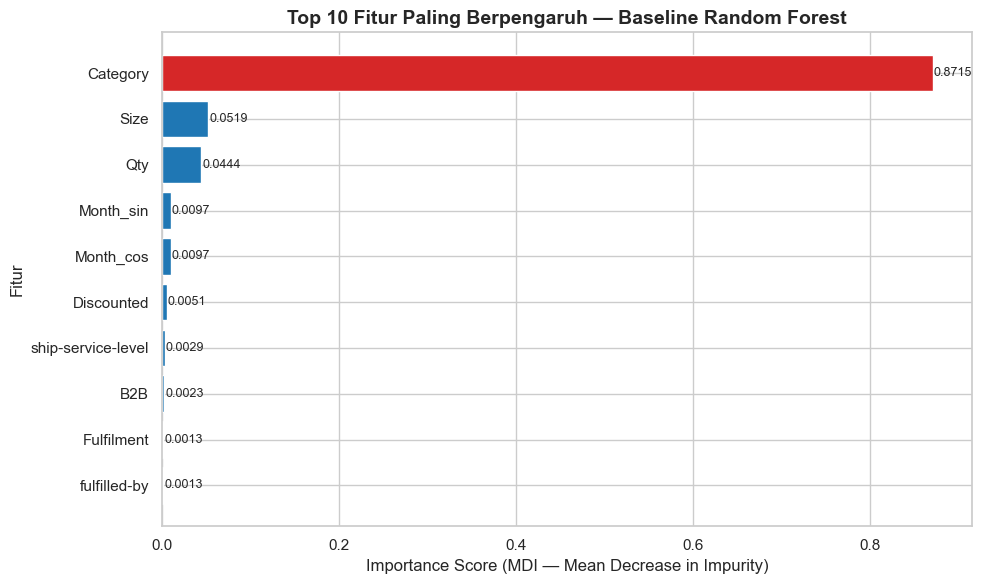


Interpretasi Feature Importance:
   Fitur dengan skor tinggi paling banyak mengurangi impurity (error) di decision tree.
   Karena encoding konsisten (bukan OHE), setiap baris mewakili SATU fitur asli.

Top 5 Fitur:
  Category                  → Importance: 0.8715
  Size                      → Importance: 0.0519
  Qty                       → Importance: 0.0444
  Month_sin                 → Importance: 0.0097
  Month_cos                 → Importance: 0.0097


In [ ]:
feature_importances = pd.Series(rf_baseline.feature_importances_, index=x_train.columns)
top_10 = feature_importances.nlargest(10).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if v < top_10.max() * 0.5 else '#d62728' for v in top_10.values]
bars = plt.barh(top_10.index, top_10.values, color=colors, edgecolor='white')
plt.title('Top 10 Fitur Paling Berpengaruh — Baseline Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (MDI — Mean Decrease in Impurity)')
plt.ylabel('Fitur')
for bar, val in zip(bars, top_10.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInterpretasi Feature Importance:")
print("   Fitur dengan skor tinggi paling banyak mengurangi impurity (error) di decision tree.")
print("   Karena encoding konsisten (bukan OHE), setiap baris mewakili SATU fitur asli.")
print()
print("Top 5 Fitur:")
for feat, score in feature_importances.nlargest(5).items():
    print(f"  {feat:<25} → Importance: {score:.4f}")


# **Hyperparameter Tuning & Cross-Validation**

## Step 1: K-Fold Cross-Validation Setup

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("K-Fold Cross-Validation Configuration:")
print(f"  Number of Folds : {kf.n_splits}")
print(f"  Shuffle         : True")
print(f"  Random State    : 42")

print("\n--- Baseline Model Cross-Validation (R²) ---")
cv_scores_baseline = cross_val_score(
    rf_baseline, x_train, y_train,
    cv=kf, scoring='r2', n_jobs=-1
)
print(f"  CV Scores per Fold : {np.round(cv_scores_baseline, 4)}")
print(f"  Mean CV R²         : {cv_scores_baseline.mean():.4f}")
print(f"  Std Dev CV R²      : {cv_scores_baseline.std():.4f}")


K-Fold Cross-Validation Configuration:
  Number of Folds : 5
  Shuffle         : True
  Random State    : 42

--- Baseline Model Cross-Validation (R²) ---
  CV Scores per Fold : [0.4946 0.4974 0.501  0.4981 0.5072]
  Mean CV R²         : 0.4997
  Std Dev CV R²      : 0.0043


## Step 2: Define Hyperparameter Search Space

In [ ]:
param_grid_random = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 8],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'        : [True, False]
}

print("Hyperparameter Search Space (RandomizedSearchCV):")
print("-" * 50)
total_combinations = 1
for param, values in param_grid_random.items():
    print(f"  {param:<20}: {values}")
    total_combinations *= len(values)
print("-" * 50)
print(f"  Total possible combinations : {total_combinations:,}")
print(f"  RandomizedSearchCV will sample 50 combinations (n_iter=50)")


Hyperparameter Search Space (RandomizedSearchCV):
--------------------------------------------------
  n_estimators        : [100, 200, 300, 500]
  max_depth           : [None, 10, 20, 30, 50]
  min_samples_split   : [2, 5, 10, 20]
  min_samples_leaf    : [1, 2, 4, 8]
  max_features        : ['sqrt', 'log2', 0.3, 0.5]
  bootstrap           : [True, False]
--------------------------------------------------
  Total possible combinations : 2,560
  RandomizedSearchCV will sample 50 combinations (n_iter=50)


## Step 3: Phase 1 — RandomizedSearchCV (Broad Search)

In [ ]:
print("Running Phase 1: RandomizedSearchCV...")
print("(This may take several minutes depending on your machine)\n")

start_time = time.time()

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_random,
    n_iter=50, cv=kf, scoring='r2',
    verbose=1, random_state=42, n_jobs=-1, return_train_score=True
)
rf_random_search.fit(x_train, y_train)

elapsed = time.time() - start_time
print(f"\nPhase 1 completed in {elapsed:.1f} seconds")
print(f"Best R² Score (CV)  : {rf_random_search.best_score_:.4f}")
print(f"Best Parameters     : {rf_random_search.best_params_}")


Running Phase 1: RandomizedSearchCV...
(This may take several minutes depending on your machine)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Phase 1 completed in 124.2 seconds
Best R² Score (CV)  : 0.5019
Best Parameters     : {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None, 'bootstrap': False}


## Step 4: Phase 2 — GridSearchCV (Refined Narrow Search)

In [ ]:
best_p = rf_random_search.best_params_

def neighbors(val, options):
    if val not in options:
        options = sorted(options + [val])
    idx = options.index(val)
    return list(set([options[max(0, idx-1)], val, options[min(len(options)-1, idx+1)]]))

param_grid_fine = {
    'n_estimators'     : neighbors(best_p['n_estimators'], [100, 200, 300, 500]),
    'max_depth'        : [best_p['max_depth']],
    'min_samples_split': neighbors(best_p['min_samples_split'], [2, 5, 10, 20]),
    'min_samples_leaf' : neighbors(best_p['min_samples_leaf'], [1, 2, 4, 8]),
    'max_features'     : [best_p['max_features']],
    'bootstrap'        : [best_p['bootstrap']]
}

print("Refined Search Space (GridSearchCV):")
total_fine = 1
for param, values in param_grid_fine.items():
    print(f"  {param:<20}: {values}")
    total_fine *= len(values)
print(f"  Total combinations to evaluate : {total_fine}\n")

print("Running Phase 2: GridSearchCV...")
start_time = time.time()

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_fine,
    cv=kf, scoring='r2', verbose=1, n_jobs=-1, return_train_score=True
)
rf_grid_search.fit(x_train, y_train)

elapsed = time.time() - start_time
print(f"\nPhase 2 completed in {elapsed:.1f} seconds")
print(f"Best R² Score (CV)  : {rf_grid_search.best_score_:.4f}")
print(f"Best Parameters     : {rf_grid_search.best_params_}")


Refined Search Space (GridSearchCV):
  n_estimators        : [200, 300, 500]
  max_depth           : [None]
  min_samples_split   : [10, 20]
  min_samples_leaf    : [1, 2, 4]
  max_features        : [0.5]
  bootstrap           : [False]
  Total combinations to evaluate : 18

Running Phase 2: GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Phase 2 completed in 70.3 seconds
Best R² Score (CV)  : 0.5019
Best Parameters     : {'bootstrap': False, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 20, 'n_estimators': 500}


## Step 5: Extract & Lock Best Model

In [ ]:
rf_tuned          = rf_grid_search.best_estimator_
best_params_final = rf_grid_search.best_params_

print("=" * 55)
print("       FINAL OPTIMAL MODEL — PARAMETER SUMMARY")
print("=" * 55)
print(f"  {'Parameter':<22} {'Value'}")
print("-" * 55)
for param, value in best_params_final.items():
    print(f"  {param:<22} {value}")
print("=" * 55)
print(f"  Cross-Validated R² (CV) : {rf_grid_search.best_score_:.4f}")
print("=" * 55)


       FINAL OPTIMAL MODEL — PARAMETER SUMMARY
  Parameter              Value
-------------------------------------------------------
  bootstrap              False
  max_depth              None
  max_features           0.5
  min_samples_leaf       2
  min_samples_split      20
  n_estimators           500
  Cross-Validated R² (CV) : 0.5019


## Step 6: Cross-Validation Score Comparison Table

In [ ]:
cv_scores_tuned = cross_val_score(
    rf_tuned, x_train, y_train, cv=kf, scoring='r2', n_jobs=-1
)

comparison_df = pd.DataFrame({
    'Model'         : ['Baseline RF', 'Tuned RF (GridSearchCV)'],
    'CV Mean R²'    : [cv_scores_baseline.mean(), cv_scores_tuned.mean()],
    'CV Std R²'     : [cv_scores_baseline.std(),  cv_scores_tuned.std()],
    'CV Fold Scores': [
        str(np.round(cv_scores_baseline, 4).tolist()),
        str(np.round(cv_scores_tuned,    4).tolist())
    ]
})
print("Cross-Validation Performance Comparison:")
print(comparison_df.to_string(index=False))


Cross-Validation Performance Comparison:
                  Model  CV Mean R²  CV Std R²                           CV Fold Scores
            Baseline RF    0.499680   0.004283  [0.4946, 0.4974, 0.501, 0.4981, 0.5072]
Tuned RF (GridSearchCV)    0.501901   0.004060 [0.4969, 0.4988, 0.5054, 0.5006, 0.5077]


## Step 7: Visualize Cross-Validation Scores per Fold

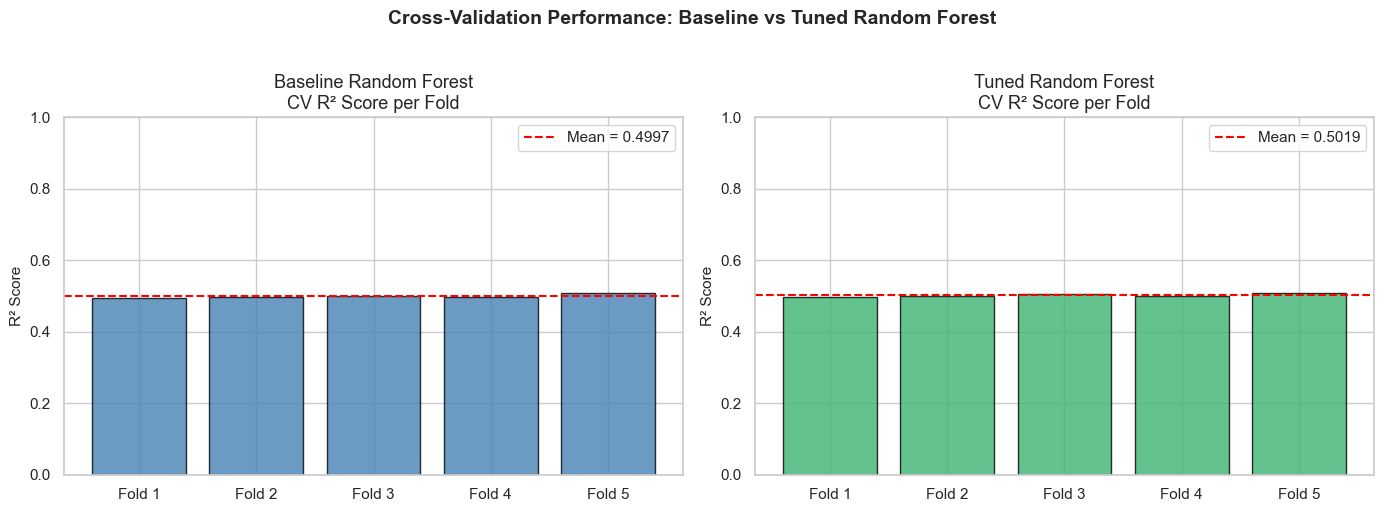

Plot saved as cv_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = [f'Fold {i+1}' for i in range(5)]

axes[0].bar(folds, cv_scores_baseline, color='steelblue', alpha=0.8, edgecolor='black')
axes[0].axhline(y=cv_scores_baseline.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {cv_scores_baseline.mean():.4f}')
axes[0].set_title('Baseline Random Forest\nCV R² Score per Fold', fontsize=13)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_ylim(0, 1)
axes[0].legend()

axes[1].bar(folds, cv_scores_tuned, color='mediumseagreen', alpha=0.8, edgecolor='black')
axes[1].axhline(y=cv_scores_tuned.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean = {cv_scores_tuned.mean():.4f}')
axes[1].set_title('Tuned Random Forest\nCV R² Score per Fold', fontsize=13)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Cross-Validation Performance: Baseline vs Tuned Random Forest',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as cv_comparison.png")


## Step 8: Final Hyperparameter Tuning Result Summary Table

In [ ]:
baseline_params = {
    'n_estimators'     : 100,
    'max_depth'        : 'None (unlimited)',
    'min_samples_split': 2,
    'min_samples_leaf' : 1,
    'max_features'     : '1.0 (all)',
    'bootstrap'        : True
}
tuned_params = {k: v for k, v in best_params_final.items()}

summary_rows = []
for param in baseline_params:
    summary_rows.append({
        'Parameter'     : param,
        'Baseline Value': baseline_params[param],
        'Optimal Value' : tuned_params.get(param, '-')
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 60)
print("   HYPERPARAMETER TUNING SUMMARY — BASELINE vs OPTIMAL")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)
print(f"  Baseline CV R²  : {cv_scores_baseline.mean():.4f} ± {cv_scores_baseline.std():.4f}")
print(f"  Tuned CV R²     : {cv_scores_tuned.mean():.4f} ± {cv_scores_tuned.std():.4f}")
print(f"  Improvement     : +{(cv_scores_tuned.mean() - cv_scores_baseline.mean()):.4f}")
print("=" * 60)


   HYPERPARAMETER TUNING SUMMARY — BASELINE vs OPTIMAL
        Parameter   Baseline Value Optimal Value
     n_estimators              100           500
        max_depth None (unlimited)          None
min_samples_split                2            20
 min_samples_leaf                1             2
     max_features        1.0 (all)           0.5
        bootstrap             True         False
  Baseline CV R²  : 0.4997 ± 0.0043
  Tuned CV R²     : 0.5019 ± 0.0041
  Improvement     : +0.0022


## Reevaluate Model

In [ ]:
y_pred_tuning = rf_tuned.predict(x_test)

tuned_r2   = r2_score(y_test, y_pred_tuning)
tuned_mae  = mean_absolute_error(y_test, y_pred_tuning)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuning))

print("Tuned Model Performance")
print(f"R-squared Score : {tuned_r2:.4f}")
print(f"MAE             : {tuned_mae:.2f} INR")
print(f"RMSE            : {tuned_rmse:.2f} INR")


Tuned Model Performance
R-squared Score : 0.5054
MAE             : 139.69 INR
RMSE            : 191.48 INR


## Feature Importance of Tuned Model

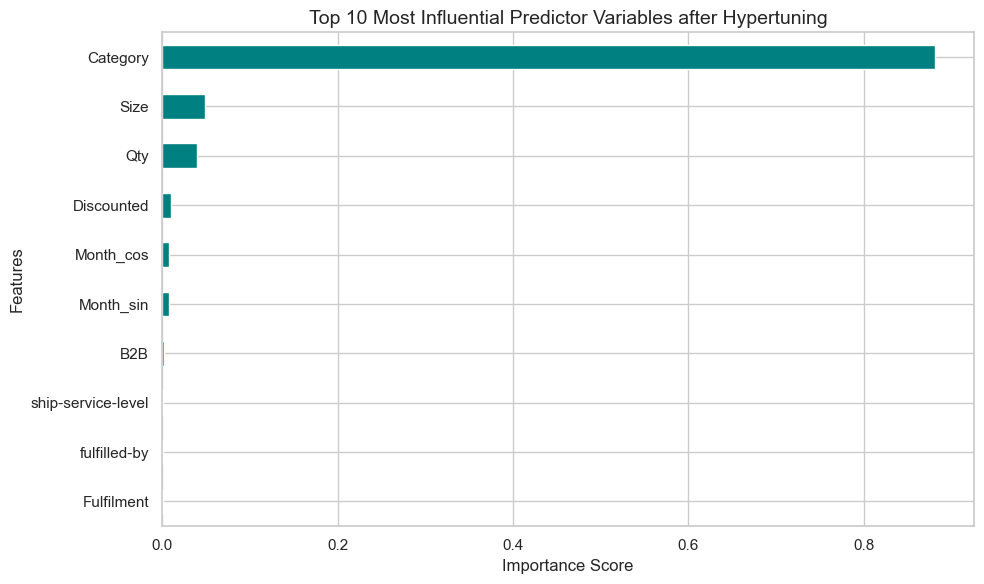

In [ ]:
tuned_feature_importances = pd.Series(rf_tuned.feature_importances_, index=x_train.columns)
top_10_tuned_features = tuned_feature_importances.nlargest(10).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#1f77b4' if v < top_10.max() * 0.5 else '#d62728' for v in top_10_tuned_features.values]
bars = plt.barh(top_10_tuned_features.index, top_10_tuned_features.values, color=colors, edgecolor='white')
plt.title('Top 10 Most Influential Predictor Variables after hypertuning', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
for bar, val in zip(bars, top_10.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# **Deployment**

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class AmazonPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, le_dict, size_map, service_map):
        self.le_dict = le_dict
        self.size_map = size_map
        self.service_map = service_map

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # 1. Boolean B2B -> integer
        df['B2B'] = df['B2B'].astype(int)

        # 2. Ordinal encoding: Size
        df['Size'] = df['Size'].map(self.size_map).fillna(len(self.size_map))

        # 3. Ordinal encoding: ship-service-level
        df['ship-service-level'] = df['ship-service-level'].map(self.service_map).fillna(0)

        # 4. Cyclical encoding: Month -> Month_sin & Month_cos
        month_map = {
            'January':1, 'February':2, 'March':3, 'April':4,
            'May':5, 'June':6, 'July':7, 'August':8,
            'September':9, 'October':10, 'November':11, 'December':12
        }
        month_num = df['Month'].map(month_map).fillna(1)
        df['Month_sin'] = np.sin(2 * np.pi * month_num / 12)
        df['Month_cos'] = np.cos(2 * np.pi * month_num / 12)
        df.drop(columns=['Month'], inplace=True)

        # 5. Label encoding using fitted le_dict from training
        for col, le in self.le_dict.items():
            if col in df.columns:
                df[col] = df[col].astype(str).apply(
                    lambda x: le.transform([x])[0] if x in le.classes_ else -1
                )

        return df


# Build pipeline using objects already fitted during training
preprocessor = AmazonPreprocessor(
    le_dict=le_dict,
    size_map=size_map,
    service_map=service_map
)

inference_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_tuned)
])

joblib.dump(inference_pipeline, 'model_pipeline.pkl')
print("Pipeline saved successfully as model_pipeline.pkl")

Pipeline saved successfully as model_pipeline.pkl


In [ ]:
def predict_amount(amazon_transaction):
    try:
        pipeline = joblib.load('model_pipeline.pkl')
    except FileNotFoundError:
        return "Error: model_pipeline.pkl not found!"

    if isinstance(amazon_transaction, dict):
        df_input = pd.DataFrame([amazon_transaction])
    else:
        df_input = pd.DataFrame(amazon_transaction)

    prediction = pipeline.predict(df_input)
    return prediction[0]

In [ ]:
pesanan_baru = {
    'Fulfilment'         : 'Amazon',
    'Sales Channel '     : 'Amazon.in',
    'ship-service-level' : 'Expedited',
    'Category'           : 'kurta',
    'Size'               : '3XL',
    'Qty'                : 2,
    'B2B'                : 0,
    'fulfilled-by'       : 'other',
    'Month'              : 'June',
    'Discounted'         : 0
}

estimasi_harga = predict_amount(pesanan_baru)
print(f"Estimated Transaction Amount (Model Prediction): {estimasi_harga:.2f} INR")

Estimated Transaction Amount (Model Prediction): 1122.86 INR
